In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!pip install -q ultralytics

In [21]:
import shutil

shutil.copy(
    '/content/drive/MyDrive/Grocery_Items.v45i.yolov8.zip',
    '/content/Grocery_Items.v45i.yolov8.zip'
)

print('Dataset copied')

Dataset copied


In [22]:
import zipfile
import os

os.makedirs('/content/dataset', exist_ok=True)

with zipfile.ZipFile('/content/Grocery_Items.v45i.yolov8.zip', 'r') as z:
    z.extractall('/content/dataset')

print('Extracted')

Extracted


In [23]:
for root, dirs, files in os.walk('/content/dataset'):
    if 'data.yaml' in files:
        dataset_root = root
        break

print(dataset_root)

/content/dataset


In [24]:
import random
import shutil
import os

small_root = '/content/small_dataset'
random.seed(42)

for split in ['train', 'valid', 'test']:
    os.makedirs(f'{small_root}/{split}/images', exist_ok=True)
    os.makedirs(f'{small_root}/{split}/labels', exist_ok=True)

ratios = {
    'train': 0.35,
    'valid': 0.50,
    'test': 0.50
}

for split in ['train', 'valid', 'test']:
    img_dir = f'{dataset_root}/{split}/images'
    lbl_dir = f'{dataset_root}/{split}/labels'
    imgs = [x for x in os.listdir(img_dir) if x.endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(imgs)

    keep = int(len(imgs) * ratios[split])

    for img in imgs[:keep]:
        shutil.copy(f'{img_dir}/{img}', f'{small_root}/{split}/images/{img}')

        label = img.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(f'{lbl_dir}/{label}'):
            shutil.copy(f'{lbl_dir}/{label}', f'{small_root}/{split}/labels/{label}')

print('Reduced dataset ready')

Reduced dataset ready


In [25]:
import yaml

with open(f'{dataset_root}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

data['train'] = '/content/small_dataset/train/images'
data['val'] = '/content/small_dataset/valid/images'
data['test'] = '/content/small_dataset/test/images'

with open('/content/small_dataset/data.yaml', 'w') as f:
    yaml.dump(data, f)

print('New data.yaml created')

New data.yaml created


In [26]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

In [32]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/small_dataset/data.yaml',
    epochs=3,
    imgsz=256,
    batch=8,
    device='cpu',
    workers=0,
    patience=1,
    project='/content/runs/detect',
    name='quick_fast'
)

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/small_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=quick_fast, 

In [34]:
from ultralytics import YOLO

trained_model = YOLO('/content/runs/detect/quick_fast/weights/best.pt')

In [35]:
results = trained_model.predict(
    source='/content/drive/MyDrive/maggi.jpg',
    imgsz=960,
    conf=0.05,
    augment=True,
    save=True
)

print(results)

FileNotFoundError: /content/drive/MyDrive/maggi.jpg does not exist

In [36]:
import numpy as np
from PIL import Image
import os

dummy_image_path = '/content/dummy_image.jpg'

# Create a blank white image
width, height = 960, 960
img_array = np.ones((height, width, 3), dtype=np.uint8) * 255
dummy_img = Image.fromarray(img_array)
dummy_img.save(dummy_image_path)

print(f'Dummy image created at: {dummy_image_path}')

Dummy image created at: /content/dummy_image.jpg


In [37]:
results = trained_model.predict(
    source='/content/dummy_image.jpg', # Updated to use the dummy image
    imgsz=960,
    conf=0.05,
    augment=True,
    save=True
)

print(results)


image 1/1 /content/dummy_image.jpg: 960x960 (no detections), 2911.8ms
Speed: 17.1ms preprocess, 2911.8ms inference, 63.3ms postprocess per image at shape (1, 3, 960, 960)
Results saved to /content/runs/detect/predict
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: '24Mantra', 1: '3D_Fryums_Ajwah', 2: '50 50 Gol Maal', 3: '50 50 sweet and salty', 4: '50 50 top', 5: '72H_AxeSignature', 6: '8am soyachunks', 7: 'ALphonsoMangoPulp_GoldenCrown', 8: 'Aakash', 9: 'Aarambh', 10: 'Aashirvaad', 11: 'Aashirvaad_Besan', 12: 'Aashirvaad_Salt', 13: 'Aashirvaad_TurmericPowder', 14: 'Abzorb', 15: 'AcaciaHoney_KhushNuma', 16: 'Act2', 17: 'Action_Dishwash_Liquid', 18: 'ActiveSaltNeem_Toothpaste_Colgate', 19: 'ActiveSalt_Toothpaste_Colgate', 20: 'Adrenaline_48H_AxeSignature', 21: 'Agarbathi_Bansuri', 22: 'Agarbathi_Baratanatyam', 23: 'Agarbathi_Cycle', 24: 'Agarbatti_SalShakti', 25: 'Agastya', 26: 'Agrabath

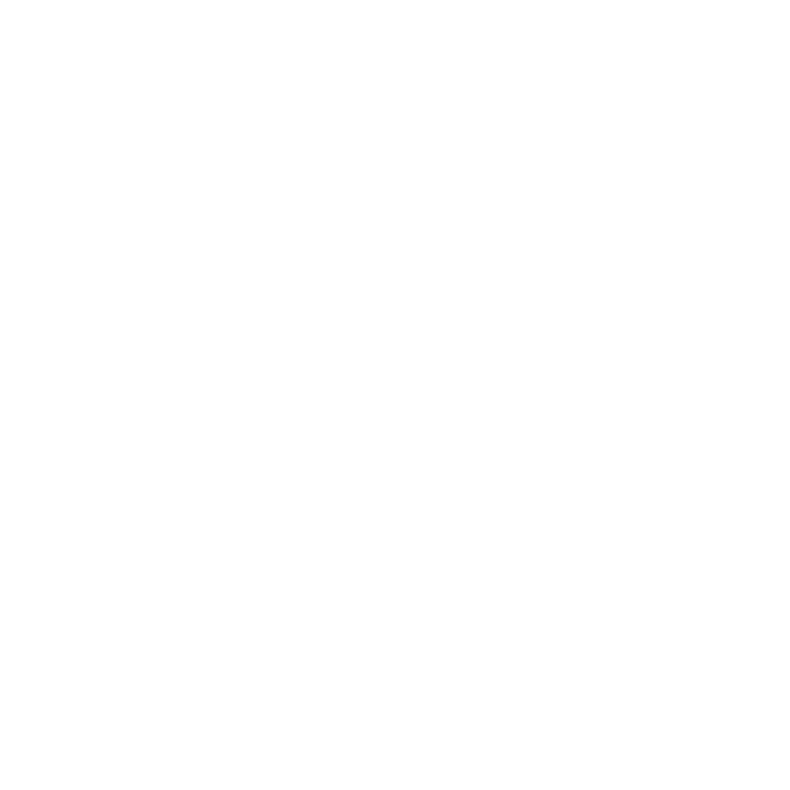

In [40]:
import matplotlib.pyplot as plt

# Directly use the plotted prediction returned by YOLO
pred_img = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(pred_img)
plt.axis('off')
plt.show()


image 1/1 /content/dummy_image.jpg: 640x640 (no detections), 1213.9ms
Speed: 5.5ms preprocess, 1213.9ms inference, 37.8ms postprocess per image at shape (1, 3, 640, 640)


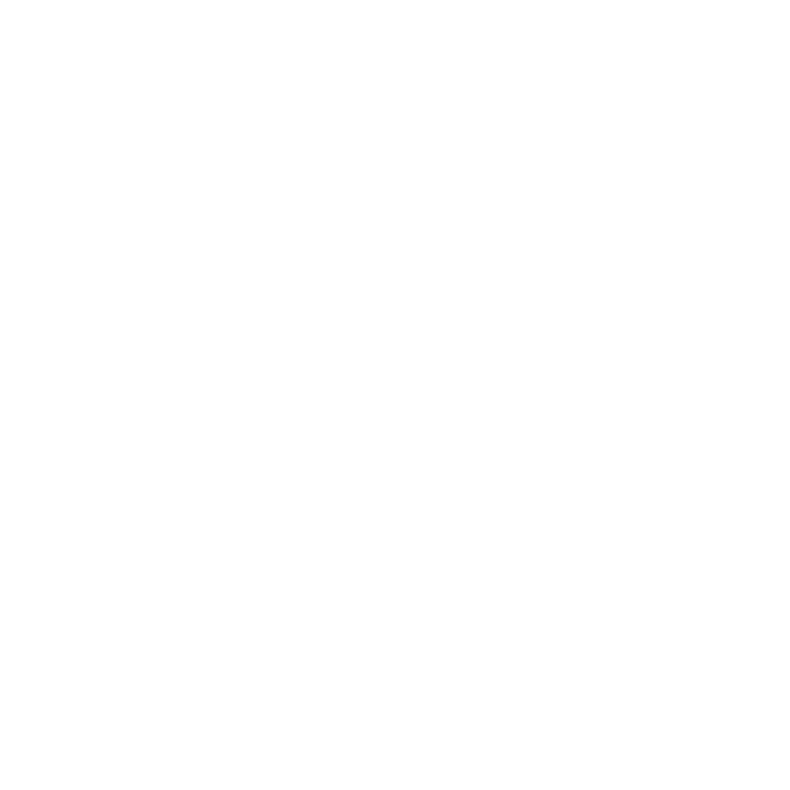

In [42]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO('/content/runs/detect/quick_fast/weights/best.pt')

results = model.predict(
    source='/content/dummy_image.jpg', # Updated to use the dummy image
    imgsz=640,
    conf=0.01,
    augment=True
)

pred_img = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(pred_img)
plt.axis('off')
plt.show()

In [44]:
import shutil

shutil.copy(
    '/content/runs/detect/quick_fast/weights/best.pt',
    '/content/drive/MyDrive/best_smart_retail.pt'
)

print('Model saved to Drive')

Model saved to Drive
